# Week 4 demo: embeddings, pixels, an API, a scrape

Run it top to bottom. Nothing is blank.

0. **Notebooks and Python**, if this is your first one.
1. **An API**, and 2. **a scrape**: two ways to get data.
3. **Words as vectors**: load a real set and play with it.
4. **Pixels**, and 5. **pictures with captions**.
6. **Your own corpus.**

> **Save a copy first:** File → Save a copy in Drive. Colab wipes its disk when the runtime ends, so save anything you want to keep to your Drive folder.

In [1]:
#@title Setup: mount Drive and pick a project folder { display-mode: "form" }
# If an import fails: re-run this cell; if it persists see ../kits/common-errors-cheatsheet.md
import os
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/culture-as-data"
except Exception:
    PROJECT_DIR = os.path.abspath("./culture-as-data-project")
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project folder:", PROJECT_DIR)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/culture-as-data


In [2]:
import re, sys, time, json
from collections import Counter

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
print("imports ok")

imports ok


## Part 0 · Notebooks and Python

A notebook is a page of cells you run one at a time.

- **Shift+Enter** runs a cell and moves on. **Ctrl+Enter** runs it and stays.
- **Code** cells are grey. **Text** cells are like this one; double-click to edit.
- What you run stays in memory, so a variable from one cell works in later cells.

In [3]:
# Run this cell twice and read the number.
runs = runs + 1 if "runs" in globals() else 1
print(f"you have run this cell {runs} time(s)")

you have run this cell 1 time(s)


The order you *ran* cells is what counts, not the order on the page. If things get strange:
**Runtime -> Restart session**, then run from the top.

In [21]:
# Python, in one cell.
title = "Frankenstein"                       # a string
year = 1818                                  # a number
words = ["ice", "fire", "night"]             # a list
counts = {"ice": 12, "fire": 4}              # a dictionary

print(f"{title} ({year}), {len(words)} words in the list")
print("first word:", words[0], "| ice appears", counts["ice"], "times")

for w in words:                              # a loop
    print("  ", w.upper())

def shout(text):                             # a function
    return text.upper() + "!"



Frankenstein (1818), 3 words in the list
first word: ice | ice appears 12 times
   ICE
   FIRE
   NIGHT
YOUR TURN!


In [5]:
# A table. Nearly everything in this course is one of these.
df = pd.DataFrame({"word": ["ice", "fire", "night"], "count": [12, 4, 33]})
print(df)
print("\nrows where count > 10:")
print(df[df["count"] > 10])

    word  count
0    ice     12
1   fire      4
2  night     33

rows where count > 10:
    word  count
0    ice     12
2  night     33


In [6]:
# Where you are. Colab gives you a small Linux machine, wiped when the runtime ends.
print("working directory:", os.getcwd())
print("python:", sys.version.split()[0])
print("files here:", sorted(os.listdir("."))[:6])

# %pip install some-package    installs for this session only
# round?                       shows help for anything

working directory: /content
python: 3.12.13
files here: ['.config', 'drive', 'sample_data']


Save what you want to keep in `PROJECT_DIR`. Everything else is deleted when the runtime stops.

## Part 1 · An API

An **endpoint** is a URL that returns data instead of a page. The Art Institute of Chicago runs
one and it needs no **key**.

Ask for one item first, and look at what comes back.

In [ ]:
# Ask for one thing and look at the whole reply before parsing it.
ART = "https://api.artic.edu/api/v1/artworks/search"

r = requests.get(ART, params={"q": "landscape", "limit": 1}, timeout=30)
print("status:", r.status_code, "  content-type:", r.headers["Content-Type"])
print("top-level keys:", list(r.json().keys()))
print()
print(json.dumps(r.json()["pagination"], indent=2))

Read `pagination` first. It tells you how many results exist and how many you get per request,
which is what decides whether you need a loop.

In [ ]:
# What fields exist? Fetch one full record and look.
one = r.json()["data"][0]
print("search results carry only:", list(one.keys()))

full = requests.get(f"https://api.artic.edu/api/v1/artworks/{one['id']}", timeout=30).json()["data"]
print(f"\nthe full record has {len(full)} fields. A sample:")
for k in ["title", "artist_title", "date_start", "place_of_origin", "medium_display",
          "color", "is_on_view"]:
    print(f"  {k:<18} {str(full.get(k))[:60]}")

Search returns a short record. To get any other field you have to name it in the request. Ask
for the fields you need and no more.

In [ ]:
# Ask wrongly on purpose. Read the error rather than retrying.
bad = requests.get(ART, params={"q": "landscape", "limit": 500}, timeout=30)
print("status:", bad.status_code)
print(json.dumps(bad.json(), indent=2)[:300])

In [ ]:
def artworks(query, pages=3, per_page=100):
    """Search the Art Institute's collection. Returns a DataFrame, one row per artwork."""
    rows = []
    for page in range(1, pages + 1):
        r = requests.get(ART, timeout=30, params={
            "q": query, "page": page, "limit": per_page,
            "fields": "title,artist_title,date_start,date_end,medium_display,place_of_origin",
        })
        r.raise_for_status()
        batch = r.json()["data"]
        if not batch:
            break
        rows += batch
        time.sleep(0.5)              # the rate limit, respected by hand
    return pd.DataFrame(rows)

art = artworks("landscape")
print(art.shape)
art.head(4)

In [ ]:
# It is a table now, so the Week 1 and 2 moves all work again.
print("artists with the most landscapes here:")
print(art["artist_title"].value_counts().head(5).to_string())

years = pd.to_numeric(art["date_start"], errors="coerce")
print(f"\nyears run {years.min():.0f} to {years.max():.0f}, "
      f"{years.isna().sum()} rows with no year at all")

plt.figure(figsize=(7, 3.2))
years.dropna().plot(kind="hist", bins=30, color="#1F5FA8")
plt.title("when the landscapes were made", loc="left")
plt.xlabel("year"); plt.tight_layout(); plt.show()

In [ ]:
# Save it. Everything you collect belongs in your Drive folder.
path = os.path.join(PROJECT_DIR, "week04_artic_landscapes.csv")
art.to_csv(path, index=False)
print("saved", len(art), "rows to", path)

### Your turn

Change `QUERY` and run the cell. Try a subject (`"shipwreck"`), a place (`"Kyoto"`), a material
(`"woodblock"`), or something from your project.

In [ ]:
QUERY = "shipwreck"          # <- change this

mine = artworks(QUERY, pages=1)
print(f"first page: {len(mine)} rows for {QUERY!r}")
if len(mine):
    print(mine[["title", "artist_title", "date_start"]].head(8).to_string(index=False))
else:
    print("nothing came back. A query that matches nothing returns an empty list, not an error.")

### A second API, shaped differently

The Met's search does not return artworks. It returns **ID numbers**, and you fetch each artwork
separately. That is one extra request per row.

In [ ]:
MET = "https://collectionapi.metmuseum.org/public/collection/v1"

def met_search(query, take=3, pause=0.5):
    """Search returns IDs only; each object needs its own request."""
    hits = requests.get(f"{MET}/search", params={"q": query, "hasImages": "true"},
                        timeout=30).json()
    print(f"{hits['total']:,} objects match {query!r}. Fetching {take} of them one at a time.")
    rows = []
    for oid in (hits["objectIDs"] or [])[:take]:
        o = requests.get(f"{MET}/objects/{oid}", timeout=30).json()
        rows.append({k: o.get(k) for k in ("objectID", "title", "artistDisplayName",
                                           "objectDate", "medium")})
        time.sleep(pause)
    return pd.DataFrame(rows)

try:
    met = met_search("storm")
    print(met.to_string(index=False))
except Exception as e:
    print("Met API unreachable:", type(e).__name__)

One API returns rows. The other returns ID numbers. Before you write a loop, work out which kind
you have and how many requests it will take.

## Part 2 · A scrape

No file and no API: then a scrape. [quotes.toscrape.com](https://quotes.toscrape.com/) is a site
built for practising on.

1. Read `robots.txt` and the terms before the first request.
2. Pause between pages.
3. Take only the fields you need.
4. Never republish the text.

In [7]:
# Rule 1: ask the site what it allows.
from urllib.robotparser import RobotFileParser

SITE = "https://quotes.toscrape.com"
rp = RobotFileParser()
rp.set_url(SITE + "/robots.txt")
try:
    rp.read()
    print("may we fetch the front page?", rp.can_fetch("*", SITE + "/page/1/"))
except Exception as e:
    print("couldn't read robots.txt:", type(e).__name__, "- treat that as a no")

may we fetch the front page? True


### Where is the data in the page?

An API gives you named fields. A web page gives you HTML, and finding the data inside it is most
of the work. Fetch one page and look at it before writing anything.

In [8]:
from bs4 import BeautifulSoup

page = requests.get(f"{SITE}/page/1/", timeout=20,
                    headers={"User-Agent": "culture-as-data course notebook"})
print(page.status_code, len(page.text), "characters of HTML\n")
print(page.text[:400])

200 11021 characters of HTML

<!DOCTYPE html>
<html lang="en">
<head>
	<meta charset="UTF-8">
	<title>Quotes to Scrape</title>
    <link rel="stylesheet" href="/static/bootstrap.min.css">
    <link rel="stylesheet" href="/static/main.css">
    
    
</head>
<body>
    <div class="container">
        <div class="row header-box">
            <div class="col-md-8">
                <h1>
                    <a href="/" style="text-


In [9]:
# In the browser: right-click a quote, Inspect, and read the tag names off the panel.
# Here: pull out one block and look at how it is built.
soup = BeautifulSoup(page.text, "html.parser")
block = soup.select_one("div.quote")
print(block.prettify()[:520])

<div class="quote" itemscope="" itemtype="http://schema.org/CreativeWork">
 <span class="text" itemprop="text">
  “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
 </span>
 <span>
  by
  <small class="author" itemprop="author">
   Albert Einstein
  </small>
  <a href="/author/Albert-Einstein">
   (about)
  </a>
 </span>
 <div class="tags">
  Tags:
  <meta class="keywords" content="change,deep-thoughts,thinking,world" itemprop="keywords"/>
  <a class


`div.quote` is one quote. Inside it, `span.text` is the words, `small.author` the name, `a.tag`
each tag. Build the selectors one at a time on this block before putting them in a loop.

In [ ]:
print("text  :", block.select_one("span.text").get_text(strip=True))
print("author:", block.select_one("small.author").get_text(strip=True))
print("tags  :", [t.get_text(strip=True) for t in block.select("a.tag")])

# The commonest scraping bug: a selector that matches nothing returns None, silently.
print("\nwrong selector:", block.select_one("span.quote-text"))

### When do I stop?

The site does not tell you how many pages there are, so keep going until a page comes back with
no quotes on it. That is the `if not blocks: break` below.

In [ ]:
def scrape_quotes(pages=4, pause=1.0):
    """Rules 2 and 3: slowly, and only the three fields we actually use."""
    rows = []
    for page in range(1, pages + 1):
        r = requests.get(f"{SITE}/page/{page}/", timeout=20,
                         headers={"User-Agent": "culture-as-data course notebook"})
        r.raise_for_status()
        soup = BeautifulSoup(r.text, "html.parser")
        blocks = soup.select("div.quote")
        if not blocks:
            break
        for q in blocks:
            rows.append({
                "text": q.select_one("span.text").get_text(strip=True),
                "author": q.select_one("small.author").get_text(strip=True),
                "tags": ", ".join(t.get_text(strip=True) for t in q.select("a.tag")),
            })
        time.sleep(pause)
    return pd.DataFrame(rows)

try:
    quotes = scrape_quotes()
except Exception as e:
    print("scrape failed:", type(e).__name__, "- using a small saved sample instead")
    quotes = pd.DataFrame({
        "text": ["“The world as we have created it is a process of our thinking.”",
                 "“It is our choices that show what we truly are.”"],
        "author": ["Albert Einstein", "J.K. Rowling"],
        "tags": ["change, thinking", "choices"]})
print(quotes.shape)
quotes.head(3)

In [ ]:
# The same table moves again: who is quoted most, and what tags travel together?
print(quotes["author"].value_counts().head(5).to_string())
print("\nmost common tags:")
print(pd.Series(", ".join(quotes["tags"]).split(", ")).value_counts().head(8).to_string())

quotes.to_csv(os.path.join(PROJECT_DIR, "week04_quotes.csv"), index=False)
print("\nsaved to your project folder")

### What it looks like when you run off the end

In [ ]:
# Page 100 is not an error. It is a page with nothing on it.
far = requests.get(f"{SITE}/page/100/", timeout=20,
                   headers={"User-Agent": "culture-as-data course notebook"})
found = BeautifulSoup(far.text, "html.parser").select("div.quote")
print("status:", far.status_code, "  quotes found:", len(found))
print("which is why the loop checks the contents, not the status code")

### Your turn

Raise `pages` and see how much the pause adds. That pause is what keeps the requests to a rate
the site can ignore.

In [ ]:
PAGES = 6                # <- try 2, then 10, and watch the clock

t0 = time.time()
more = scrape_quotes(pages=PAGES, pause=1.0)
print(f"{len(more)} quotes from {PAGES} pages in {time.time() - t0:.0f}s")
print(f"about {(time.time() - t0) / max(PAGES, 1):.1f}s per page, most of it the pause")

That scrape was fine because all four rules held.

Licensing decides first: CC0 and public domain go anywhere, academic sets and community text are
analyse-don't-redistribute, shadow libraries never. Detail in `kits/licensing-one-pager.md`.

## Part 3 · Words as vectors

To ask what is *near* what, each word has to be a list of numbers.

Counting cannot do it. In a **bag of words** every word gets its own column, and nothing
connects one column to another.

The fix is older than the computers:

> "The meaning of a word is its use in the language."
> — Wittgenstein, *Philosophical Investigations* §43 (1953)
>
> "You shall know a word by the company it keeps."
> — J. R. Firth, *A Synopsis of Linguistic Theory 1930-1955* (1957)

That is the **distributional hypothesis** (Zellig Harris, 1954): words used in similar contexts
tend to mean similar things. Set each word's numbers from the company it keeps, and words used
alike end up near each other.

**GloVe** did exactly that on six billion words of Wikipedia and news. Download it and look.

In [11]:
# 66 MB, about ten seconds. Cached in your Drive folder, so it only downloads once.
import gzip, urllib.request

GLOVE_URL = ("https://github.com/RaRe-Technologies/gensim-data/releases/download/"
             "glove-wiki-gigaword-50/glove-wiki-gigaword-50.gz")
glove_file = os.path.join(PROJECT_DIR, "glove-50d.gz")
if not os.path.exists(glove_file):
    urllib.request.urlretrieve(GLOVE_URL, glove_file)

KEEP = 50000                                   # the 50,000 commonest words is plenty
vocab, rows = [], []
with gzip.open(glove_file, "rt", encoding="utf-8") as f:
    next(f)                                    # the first line is just the shape
    for i, line in enumerate(f):
        if i >= KEEP:
            break
        parts = line.rstrip().split(" ")
        vocab.append(parts[0]); rows.append(parts[1:])

glove = np.array(rows, dtype=np.float32)
glove /= np.linalg.norm(glove, axis=1, keepdims=True) + 1e-9    # length 1, so dot = cosine
at = {w: i for i, w in enumerate(vocab)}
print(glove.shape, "- fifty numbers for each of", f"{len(vocab):,}", "words")

(50000, 50) - fifty numbers for each of 50,000 words


In [12]:
def nearest(word, k=8):
    """The k words pointing most nearly the same way."""
    if word not in at:
        return ["(not in the vocabulary)"]
    sims = glove @ glove[at[word]]
    return [vocab[i] for i in np.argsort(-sims) if vocab[i] != word][:k]

for w in ["museum", "gothic", "vampire", "novel", "reddit"]:
    print(f"{w:>8}  ->  {', '.join(nearest(w, 6))}")

  museum  ->  art, gallery, library, exhibition, museums, heritage
  gothic  ->  romanesque, baroque, medieval, façade, mediaeval, revival
 vampire  ->  werewolf, beast, witch, vampires, slayer, villain
   novel  ->  fiction, adaptation, novels, book, biography, story
  reddit  ->  (not in the vocabulary)


### Your turn

Put your own words in. Try something from the corpus you just collected, a name, a genre, a
piece of slang. Some will not be there: GloVe is from 2014.

In [13]:
for w in ["curator", "haunted", "manuscript"]:      # <- change these
    print(f"{w:>12}  ->  {', '.join(nearest(w, 6))}")

     curator  ->  smithsonian, paleontologist, museum, archaeologist, corcoran, anthropologist
     haunted  ->  haunts, haunt, ghost, ghosts, forgotten, mystery
  manuscript  ->  manuscripts, unpublished, testament, extant, inscription, texts


In [14]:
# Two words, one number.
def similarity(a, b):
    if a not in at or b not in at:
        return float("nan")
    return float(glove[at[a]] @ glove[at[b]])

for a, b in [("king", "queen"), ("king", "chair"), ("museum", "gallery"),
             ("gothic", "romantic"), ("cat", "dog"), ("cat", "algebra")]:
    print(f"{a:>8} . {b:<10} {similarity(a, b):+.2f}")

    king . queen      +0.78
    king . chair      +0.29
  museum . gallery    +0.79
  gothic . romantic   +0.56
     cat . dog        +0.92
     cat . algebra    -0.07


In [15]:
# Directions carry relationships. a is to b as c is to what?
def analogy(a, b, c, k=3):
    for w in (a, b, c):
        if w not in at:
            return ["(not in the vocabulary)"]
    target = glove[at[b]] - glove[at[a]] + glove[at[c]]
    target /= np.linalg.norm(target)
    return [vocab[i] for i in np.argsort(-(glove @ target)) if vocab[i] not in (a, b, c)][:k]

print("man     : woman  :: king   ->", analogy("man", "woman", "king"))
print("france  : paris  :: japan  ->", analogy("france", "paris", "japan"))
print("good    : better :: bad    ->", analogy("good", "better", "bad"))
print("man     : woman  :: doctor ->", analogy("man", "woman", "doctor"))

man     : woman  :: king   -> ['queen', 'throne', 'prince']
france  : paris  :: japan  -> ['tokyo', 'shanghai', 'japanese']
good    : better :: bad    -> ['worse', 'too', 'unfortunately']
man     : woman  :: doctor -> ['nurse', 'child', 'pregnant']


Read that last line again. Nobody put it there. It is what six billion words of English had
near what, which is the finding in this week's paper, reproduced in one line of arithmetic.

Most analogies fail, by the way. The famous four are the ones that worked.

## Part 4 · Pixels

To put a painting in the same space as words, we first have to turn it into numbers. A
convolution does that.

An image is already a grid of numbers, one per pixel, 0 for black. A **filter** is a smaller
grid, usually 3x3.

1. Lay the filter over a 3x3 patch.
2. Multiply each filter number by the pixel under it.
3. Add the nine results. That is **one number**.
4. Move one pixel across and repeat. The numbers make a new image.

The next four cells are those four steps, on a real painting.

In [16]:
from scipy.signal import convolve2d
from PIL import Image

def load_painting():
    """A Met painting from the Week 1 data, or one fetched from the Met's API."""
    for base in ("data/week01/met", "notebooks/data/week01/met"):
        if os.path.isdir(base):
            files = sorted(f for f in os.listdir(base) if f.endswith(".jpg"))
            if files:
                return Image.open(os.path.join(base, files[0]))
    meta = requests.get("https://collectionapi.metmuseum.org/public/collection/v1/objects/436532",
                        timeout=30).json()
    import io
    return Image.open(io.BytesIO(requests.get(meta["primaryImageSmall"], timeout=30).content))

img = load_painting().convert("L")      # grey, so there is one number per pixel
img.thumbnail((400, 400))
pixels = np.asarray(img, dtype=float)   # 0 = black, 255 = white
print("the painting is now a grid of numbers:", pixels.shape)
print("\na 5x8 corner of it, as integers:")
print(pixels[120:125, 120:128].astype(int))

the painting is now a grid of numbers: (400, 321)

a 5x8 corner of it, as integers:
[[152 157 158 161 151 166 145 147]
 [143 162 150 163 142 165 149 165]
 [134 152 158 128 121 156 120 152]
 [137  85 131 122  62 132  71 100]
 [105  92  66 127  90 106  84  98]]


In [17]:
# Steps 1-3 by hand: one patch, one filter, one number.
vertical_edges = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], float)

patch = pixels[120:123, 120:123]        # a 3x3 patch of the painting
print("the patch:\n", patch.astype(int))
print("\nthe filter:\n", vertical_edges.astype(int))

print("\nnine multiplications:")
total = 0.0
for i in range(3):
    row = []
    for j in range(3):
        product = vertical_edges[i, j] * patch[i, j]
        total += product
        row.append(f"({vertical_edges[i, j]:+.0f} x {patch[i, j]:3.0f}) = {product:+7.0f}")
    print("   " + "   ".join(row))
print(f"\nadd them up  ->  {total:+.0f}      <- ONE pixel of the output image")

the patch:
 [[152 157 158]
 [143 162 150]
 [134 152 158]]

the filter:
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

nine multiplications:
   (-1 x 152) =    -152   (+0 x 157) =      +0   (+1 x 158) =    +158
   (-2 x 143) =    -286   (+0 x 162) =      +0   (+2 x 150) =    +300
   (-1 x 134) =    -134   (+0 x 152) =      +0   (+1 x 158) =    +158

add them up  ->  +44      <- ONE pixel of the output image


output image: (398, 319) (two smaller in each direction - no room at the edges)
scipy's value at the same spot: +44
ours, computed by hand:         +44


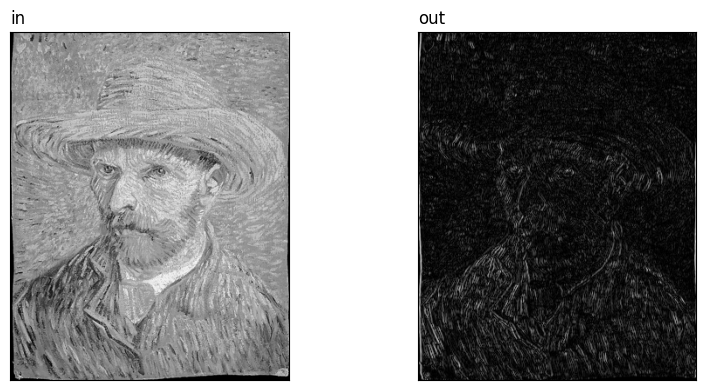

bright = the nine numbers found what they were looking for, here a vertical edge


In [18]:
# Step 4: scipy does it everywhere. Check it against the number we got by hand.
from scipy.signal import correlate2d

output = correlate2d(pixels, vertical_edges, mode="valid")
print("output image:", output.shape, "(two smaller in each direction - no room at the edges)")
print("scipy's value at the same spot:", f"{output[120, 120]:+.0f}")
print("ours, computed by hand:        ", f"{total:+.0f}")

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1); plt.imshow(pixels, cmap="gray"); plt.title("in", loc="left")
plt.subplot(1, 2, 2); plt.imshow(np.abs(output), cmap="gray"); plt.title("out", loc="left")
for ax in plt.gcf().axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("bright = the nine numbers found what they were looking for, here a vertical edge")

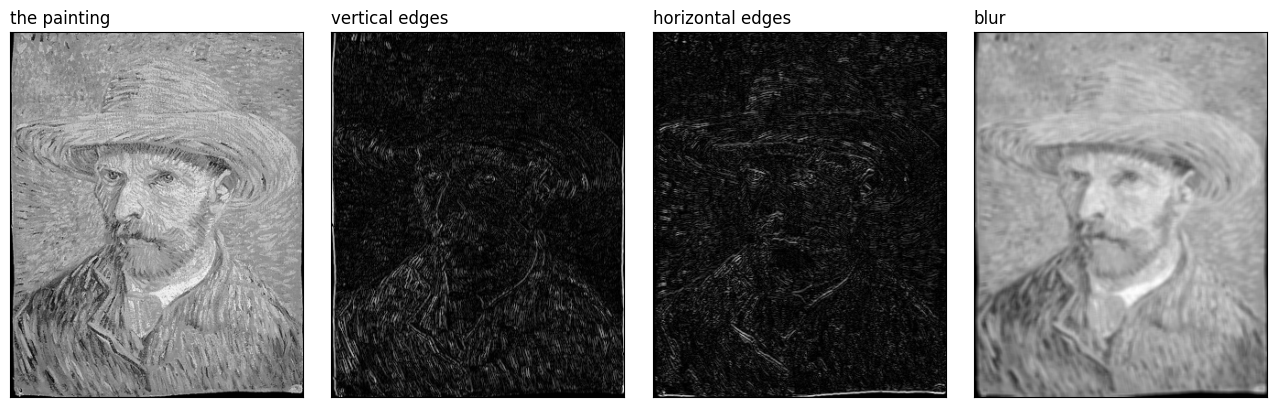

each of those is the SAME image, seen through a different 3x3 grid


In [19]:
pixels = pixels / 255      # back to 0-1, which keeps the pictures below comparable
kernels = {
    "vertical edges":   np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float),
    "horizontal edges": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], float),
    "blur":             np.ones((5, 5)) / 25,
}

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
axes[0].imshow(pixels, cmap="gray"); axes[0].set_title("the painting", loc="left")
for ax, (name, k) in zip(axes[1:], kernels.items()):
    ax.imshow(np.abs(convolve2d(pixels, k, mode="same", boundary="symm")), cmap="gray")
    ax.set_title(name, loc="left")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print("each of those is the SAME image, seen through a different 3x3 grid")

### Why a CNN is deep

Run a filter over the output of the last filter. Between layers, shrink the image by keeping the
largest number in each 2x2 block (max pooling). Each later number then covers more of the
painting, so edges turn into corners and corners into regions.

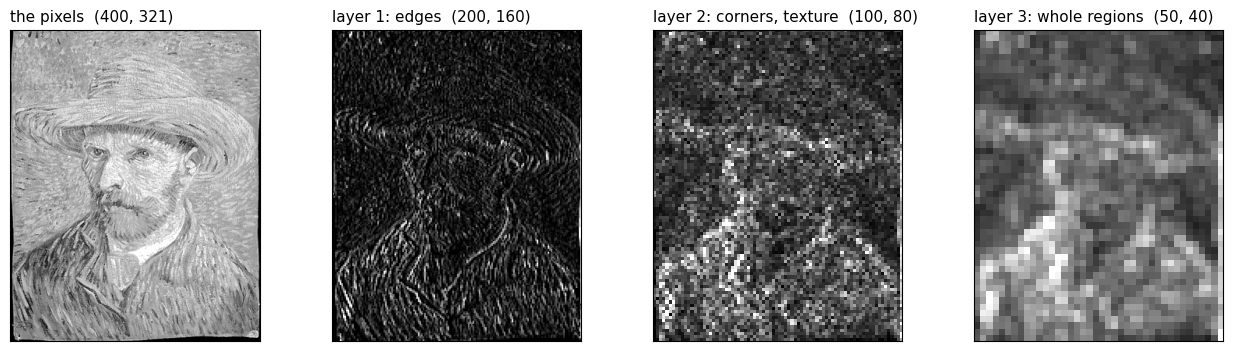

In [20]:
def pool(x, k=2):
    """Keep the largest number in each 2x2 block. The image halves in both directions."""
    h, w = (x.shape[0] // k) * k, (x.shape[1] // k) * k
    return x[:h, :w].reshape(h // k, k, w // k, k).max(axis=(1, 3))

def layer(x, kernel):
    """One CNN layer: convolve, throw away the negatives (ReLU), shrink."""
    return pool(np.maximum(convolve2d(x, kernel, mode="same", boundary="symm"), 0))

corner = np.array([[0, 1, 0], [1, -3, 1], [0, 1, 0]], float)
layer1 = layer(pixels, kernels["vertical edges"])
layer2 = layer(layer1, corner)
layer3 = layer(layer2, np.ones((3, 3)) / 9)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (m, name) in zip(axes, [(pixels, "the pixels"), (layer1, "layer 1: edges"),
                                (layer2, "layer 2: corners, texture"),
                                (layer3, "layer 3: whole regions")]):
    ax.imshow(m, cmap="gray", vmin=0, vmax=np.percentile(m, 99.5))
    ax.set_title(f"{name}  {m.shape}", loc="left", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**A real CNN picks the nine numbers itself.** We chose ours because we knew what they do. A CNN
starts them random and learns them by rolling downhill, with hundreds of filters per layer and
dozens of layers.

Same trade as the hidden layer. Nobody has to describe what an eye looks like, and nobody can
read layer 30 afterwards.

### Every painting as a list of numbers

The same filters on every painting, then ask which two land nearest. No artist, no date, no
subject.

In [ ]:
def picture_vector(path, size=128, grid=4):
    """A crude convolutional feature: how much each filter fires, in each part of the image."""
    im = Image.open(path).convert("L")
    im = im.resize((size, size))
    a = np.asarray(im, float) / 255
    out = []
    for k in kernels.values():
        r = np.abs(convolve2d(a, k, mode="same", boundary="symm"))
        step = size // grid
        # average the response in each cell of a 4x4 grid: where in the picture it fired
        out += [r[i * step:(i + 1) * step, j * step:(j + 1) * step].mean()
                for i in range(grid) for j in range(grid)]
    v = np.array(out)
    return v / (np.linalg.norm(v) + 1e-9)

met_dir = next((b for b in ("data/week01/met", "notebooks/data/week01/met")
                if os.path.isdir(b)), None)
files = sorted(f for f in os.listdir(met_dir) if f.endswith(".jpg"))
gallery = np.stack([picture_vector(os.path.join(met_dir, f)) for f in files])
print(f"{len(files)} paintings, each now {gallery.shape[1]} numbers")

sims = gallery @ gallery.T
np.fill_diagonal(sims, -1)
query = 0
match = int(np.argmax(sims[query]))
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, i, label in ((axes[0], query, "this one"), (axes[1], match, "looks most like this")):
    ax.imshow(Image.open(os.path.join(met_dir, files[i])))
    ax.set_title(f"{label}\n{files[i]}", loc="left", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print(f"similarity {sims[query, match]:.3f} - and nobody told it anything about either picture")

Try other values of `query`. Sometimes it finds a real resemblance, sometimes it has matched the
lighting of the photograph.

We now have two separate spaces. A GloVe word is 50 numbers, a painting is 48, and you cannot
compare one to the other.

## Part 5 · Pictures and captions

The same idea, with a different kind of context. For a word it was a few words of text. Here it
is a painting and the caption that belongs to it.

> Same context: the painting and *its own* title, pull together.
> Different context: *someone else's* title, push apart.

Each side gets a matrix that maps it into one shared space, so the two spaces line up. That is
CLIP. Ours has 18 pairs. The real one had 400 million.

In [ ]:
# The captions: each painting's own title, as a bag of words.
import csv
manifest = os.path.join(os.path.dirname(met_dir), "met_manifest.csv")
titles = {os.path.basename(r["file"]): r["title"] for r in csv.DictReader(open(manifest, encoding="utf-8"))}
caption = [titles.get(f, f) for f in files]

title_words = sorted({w for c in caption for w in re.findall(r"[a-z]{3,}", c.lower())})
word_at = {w: i for i, w in enumerate(title_words)}

def bag(text):
    v = np.zeros(len(title_words))
    for w in re.findall(r"[a-z]{3,}", text.lower()):
        if w in word_at:
            v[word_at[w]] += 1
    return v / (np.linalg.norm(v) + 1e-9)

captions = np.stack([bag(c) for c in caption])
print(f"{len(title_words)} words across {len(caption)} titles")
print("example pair:", files[0], "<->", caption[0])

In [ ]:
# Train the two matrices together. The diagonal is the same context; everything else is not.
SHARED, STEPS, RATE = 12, 2000, 0.05
n = len(files)
same = np.eye(n)

def unit(m):
    return m / (np.linalg.norm(m, axis=1, keepdims=True) + 1e-9)

def softmax(m):
    e = np.exp(m - m.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

rng = np.random.default_rng(0)
Wimg = rng.normal(0, 0.3, (gallery.shape[1], SHARED))
Wtxt = rng.normal(0, 0.3, (len(title_words), SHARED))

for step in range(STEPS):
    img, txt = unit(gallery @ Wimg), unit(captions @ Wtxt)
    scores = img @ txt.T * 5                      # every painting against every caption
    # pull the diagonal up, push everything else down, in both directions
    push = ((softmax(scores) - same) + (softmax(scores.T) - same).T) * 5 / n
    Wimg -= RATE * gallery.T @ (push @ txt)
    Wtxt -= RATE * captions.T @ (push.T @ img)

img, txt = unit(gallery @ Wimg), unit(captions @ Wtxt)
hit = (( img @ txt.T).argmax(1) == np.arange(n)).mean()
print(f"picture finds its own caption {hit:.0%} of the time")

In [ ]:
# Now search the paintings with words. The pictures were never tagged with any of this.
def search(phrase, k=3):
    e = bag(phrase) @ Wtxt
    if not np.any(e):
        return print(f"'{phrase}': no word from the titles in there")
    scores = img @ (e / (np.linalg.norm(e) + 1e-9))
    best = np.argsort(-scores)[:k]
    fig, axes = plt.subplots(1, k, figsize=(4 * k, 4))
    for ax, i in zip(axes, best):
        ax.imshow(Image.open(os.path.join(met_dir, files[i])))
        ax.set_title(f"{scores[i]:+.2f}  {caption[i][:34]}", loc="left", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'"{phrase}"', x=0.02, ha="left", fontsize=13)
    plt.tight_layout(); plt.show()

search("a woman")
search("a young man in a hat")

With 18 pairs the model can just memorise them, so treat the hit rate as a demo, not a result.
The method is the point: two kinds of thing in one space, trained only on which pairs go
together.

### The real one

CLIP proper was trained the same way on 400 million picture-caption pairs. It is a download,
like GloVe was, and then you can search these paintings with any sentence you like.

In [ ]:
# About 600 MB the first time. Colab keeps it for the session.
try:
    from sentence_transformers import SentenceTransformer
    clip = SentenceTransformer("clip-ViT-B-32")
    photos = [Image.open(os.path.join(met_dir, f)) for f in files]
    pics = clip.encode(photos, normalize_embeddings=True)
    print("each painting is now", pics.shape[1], "numbers, from a model that has never seen it")
except Exception as e:
    clip = None
    print("CLIP unavailable:", type(e).__name__, e)
    print("%pip install -q sentence-transformers, then Runtime -> Restart session")

In [ ]:
def clip_search(phrase, k=3):
    scores = pics @ clip.encode([phrase], normalize_embeddings=True)[0]
    best = np.argsort(-scores)[:k]
    fig, axes = plt.subplots(1, k, figsize=(4 * k, 4))
    for ax, i in zip(axes, best):
        ax.imshow(Image.open(os.path.join(met_dir, files[i])))
        ax.set_title(f"{scores[i]:.2f}  {caption[i][:32]}", loc="left", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'"{phrase}"', x=0.02, ha="left", fontsize=13)
    plt.tight_layout(); plt.show()

if clip is not None:
    clip_search("a man in a straw hat")
    clip_search("a woman in a white headdress")

### Your turn

Nothing in these paintings is tagged. The words are yours, the pictures are the Met's, and the
model has never seen either. Try a colour, a mood, an object, a century.

In [ ]:
if clip is not None:
    clip_search("a young boy")          # <- change this

## Part 6 · Your own corpus

Vectors trained on the text you just collected.

In [ ]:
# Too few quotes to train on, so this counts co-occurrences and squashes them (PPMI + SVD):
# the shortcut to a similar geometry without the pulling and pushing.
def embed(texts, vocab_size=600, window=4, dims=30):
    toks = re.findall(r"[a-z']{2,}", " ".join(texts).lower())
    vcb = [w for w, _ in Counter(toks).most_common(vocab_size)]
    idx = {w: i for i, w in enumerate(vcb)}
    ii = [idx.get(w, -1) for w in toks]
    m = np.zeros((len(vcb), len(vcb)), dtype=np.float32)
    for i, a in enumerate(ii):
        if a < 0:
            continue
        for j in range(max(0, i - window), min(len(ii), i + window + 1)):
            b = ii[j]
            if b >= 0 and j != i:
                m[a, b] += 1
    tot, r_, c_ = m.sum(), m.sum(1, keepdims=True), m.sum(0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        p = np.log((m * tot) / (r_ * c_))
    p[~np.isfinite(p)] = 0; p[p < 0] = 0
    v = TruncatedSVD(n_components=min(dims, len(vcb) - 1), random_state=0).fit_transform(p)
    v /= np.linalg.norm(v, axis=1, keepdims=True) + 1e-9
    return v, vcb, idx

qv, qvocab, qindex = embed(quotes["text"].tolist())
print(f"vectors for {len(qvocab)} words, from {len(quotes)} quotes\n")

for w in ["life", "love", "world"]:
    if w in qindex:
        sims = qv @ qv[qindex[w]]
        print(f"{w:>6}  ->  {', '.join([qvocab[i] for i in np.argsort(-sims) if qvocab[i] != w][:6])}")

Rough vectors, but the same question you asked GloVe. A bigger corpus gives a better answer,
not a different method.

### Before Week 5

- **Data Biography**, ~400 words.
- **Your corpus, saved to Drive.** Week 5 starts from that file.
- **[Embedding Projector](https://projector.tensorflow.org/):** look up a word from your corpus.
  Bring one neighbour that makes sense and one that does not.